In [1]:
suppressPackageStartupMessages({
        library(dplyr)
        library(ggplot2)
        library(gridExtra)
        library(viridis)
        library(Matrix)
    })
options(repr.plot.width=15, repr.plot.height=5)

In [57]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"

source(paste0(main, "mapping_functions_extended.R"))
load_data()

In [58]:
sce = sce[,meta$sample==16]
meta = meta[meta$sample==16,]

In [59]:
meta$barcode = paste0(meta$barcode, '-1')

In [2]:
clusters_in = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/souporcell/mm10/'
clusters = read.csv(paste0(clusters_in, 'clusters.tsv'), sep='\t')

In [61]:
clusters$cluster0 = clusters$cluster0*-1
clusters$cluster1 = clusters$cluster1*-1

In [62]:
merge = merge(meta, clusters, by='barcode')
sce = sce[,!merge$assignment %in% c('0/1', '1/0')]
merge = merge[!merge$assignment %in% c('0/1', '1/0'),]

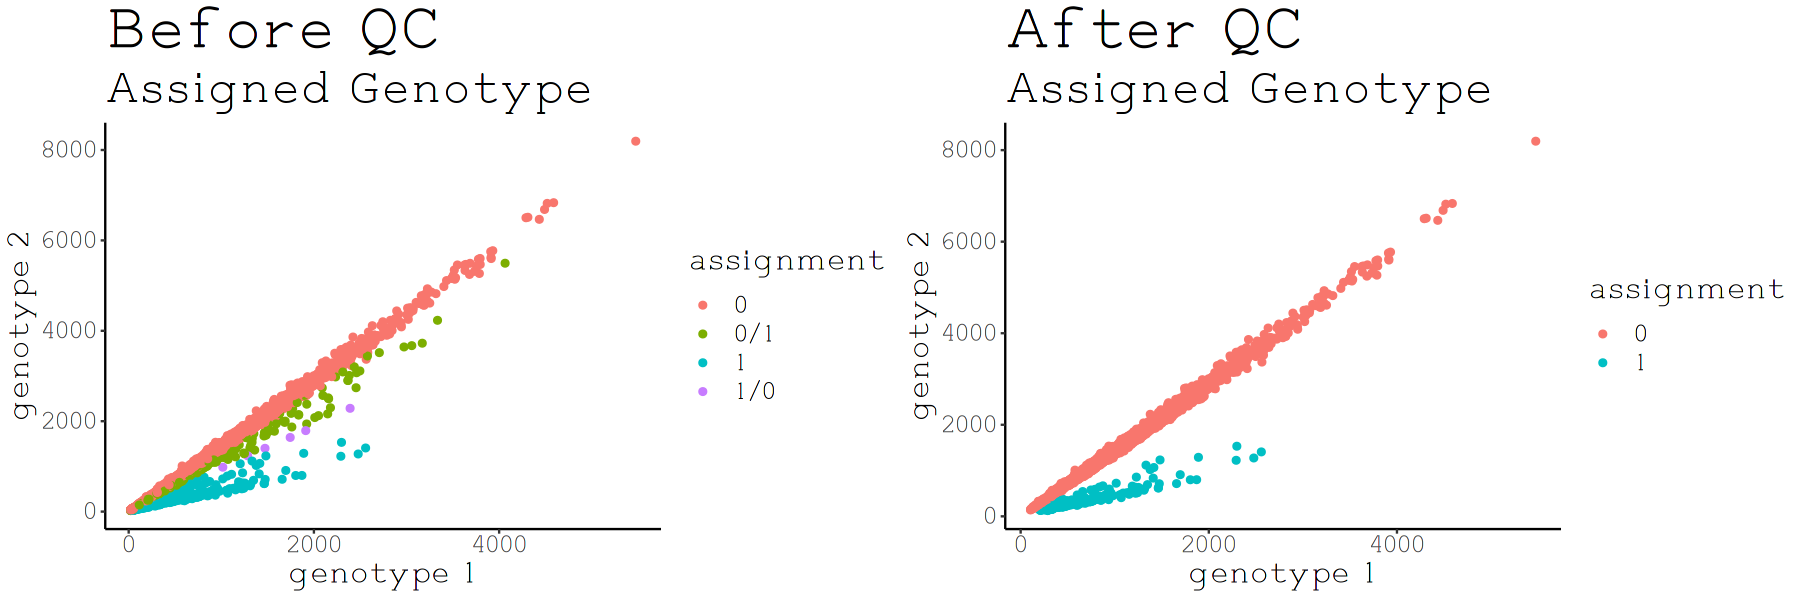

In [63]:
theme = theme(text = element_text(size=20))
p1 = ggplot(clusters, aes(cluster0, cluster1, color=assignment)) + 
    geom_point() + 
    labs(title = "Before QC",
        subtitle = "Assigned Genotype") + 
    xlab('genotype 1') + 
    ylab('genotype 2') + 
    theme_classic() + 
    theme + theme(plot.title = element_text(size=40), plot.subtitle = element_text(size = 30))
p2 = ggplot(merge, aes(cluster0, cluster1, color=assignment)) + 
    geom_point() + 
    labs(title = "After QC",
        subtitle = "Assigned Genotype") + 
    xlab('genotype 1') + 
    ylab('genotype 2') + 
    theme_classic() + 
    theme + theme(plot.title = element_text(size=40), plot.subtitle = element_text(size = 30))

grid.arrange(p1, p2, ncol = 2)


In [64]:
tdtom_count = logcounts(sce)[nrow(counts(sce)),]

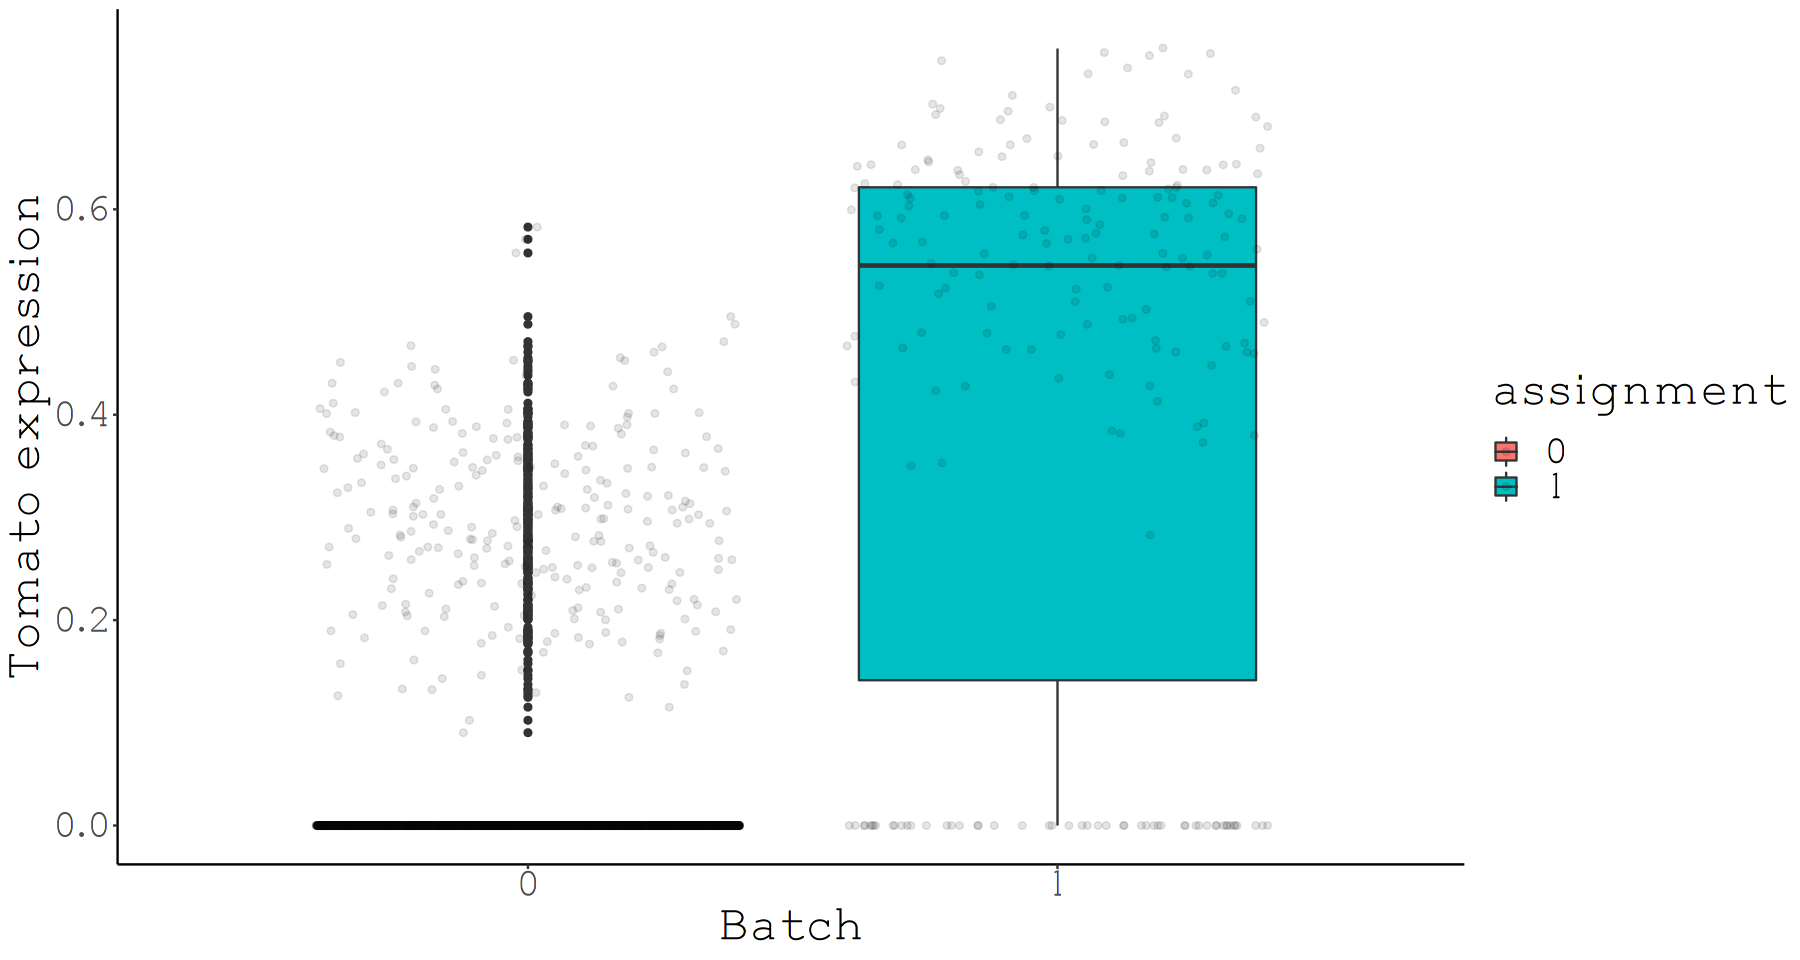

In [65]:
options(repr.plot.width=15, repr.plot.height=8)
ggplot(merge, aes(as.factor(assignment), log10(tdtom_count+1), fill=assignment)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')



## Result is as expected, will probably look better after normalisation/scaling

In [66]:
merge$tdTom[merge$assignment == 1 | tdtom_count > 0.05] = 'positive'

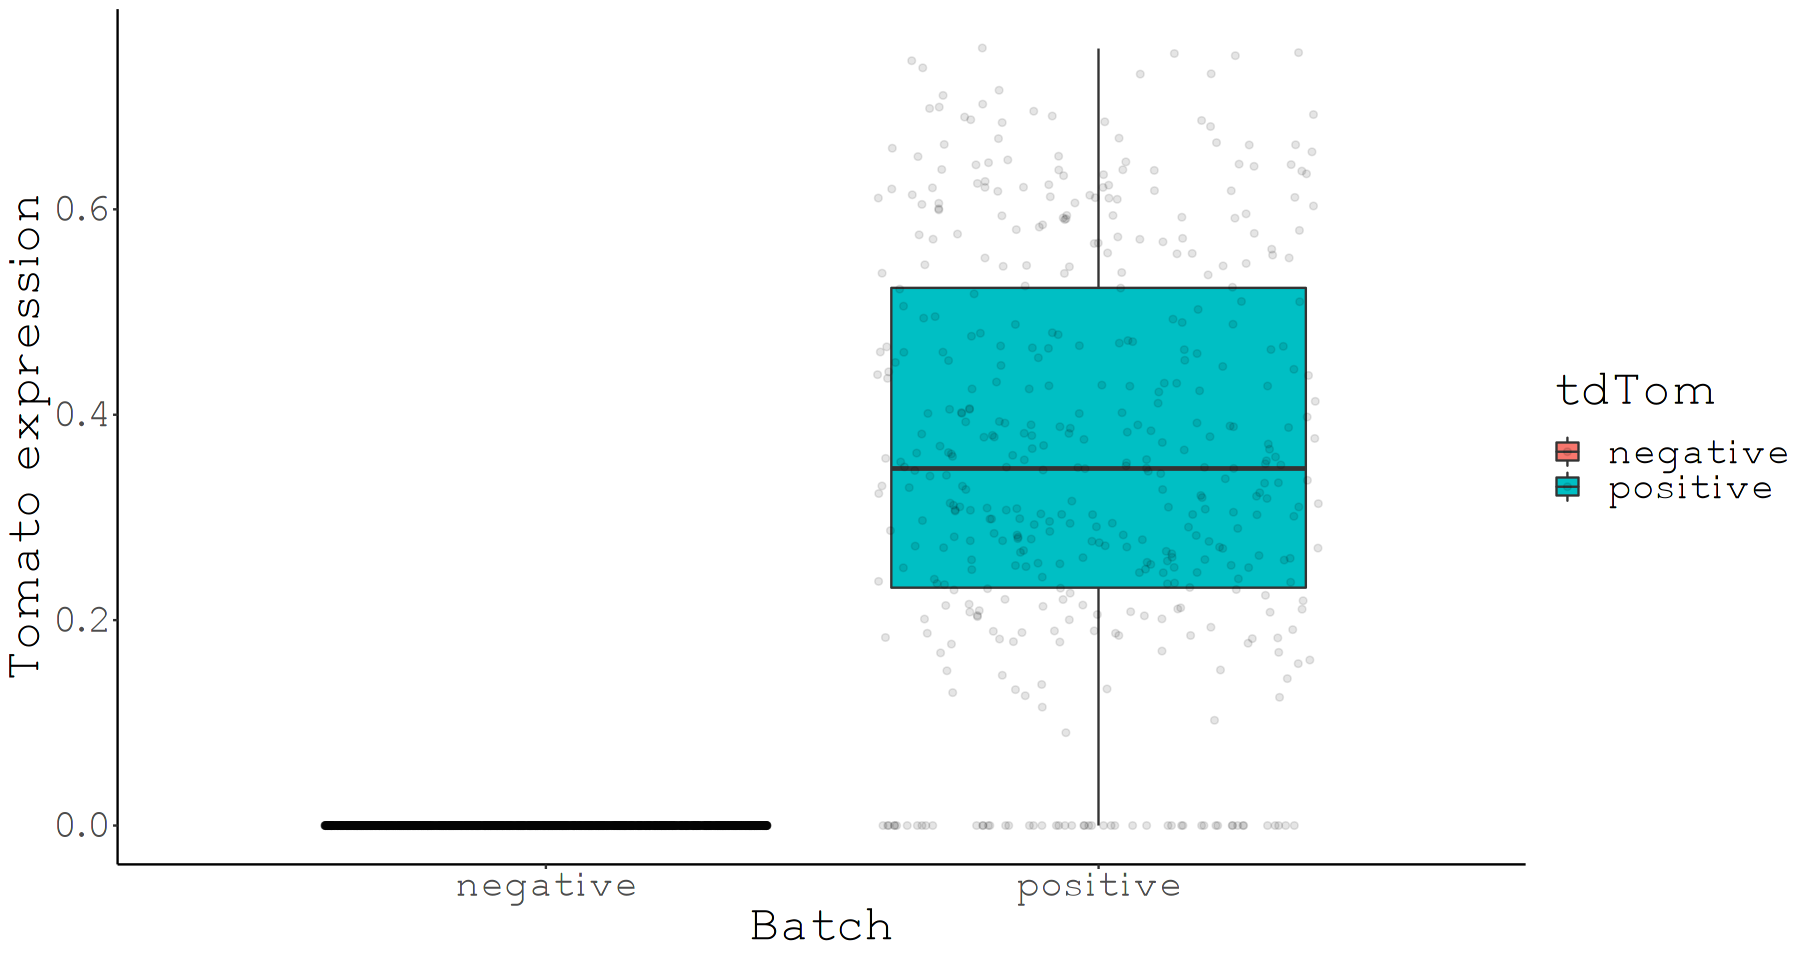

In [67]:
p6 = ggplot(merge, aes(as.factor(tdTom), log10(tdtom_count+1), fill=tdTom)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')

options(repr.plot.width=15, repr.plot.height=8)
p6
## Result is as expected, will probably look better after normalisation/scaling

In [68]:
table(merge$assignment)
table(merge$tdTom)


   0    1 
4593  207 


negative positive 
    4340      460 

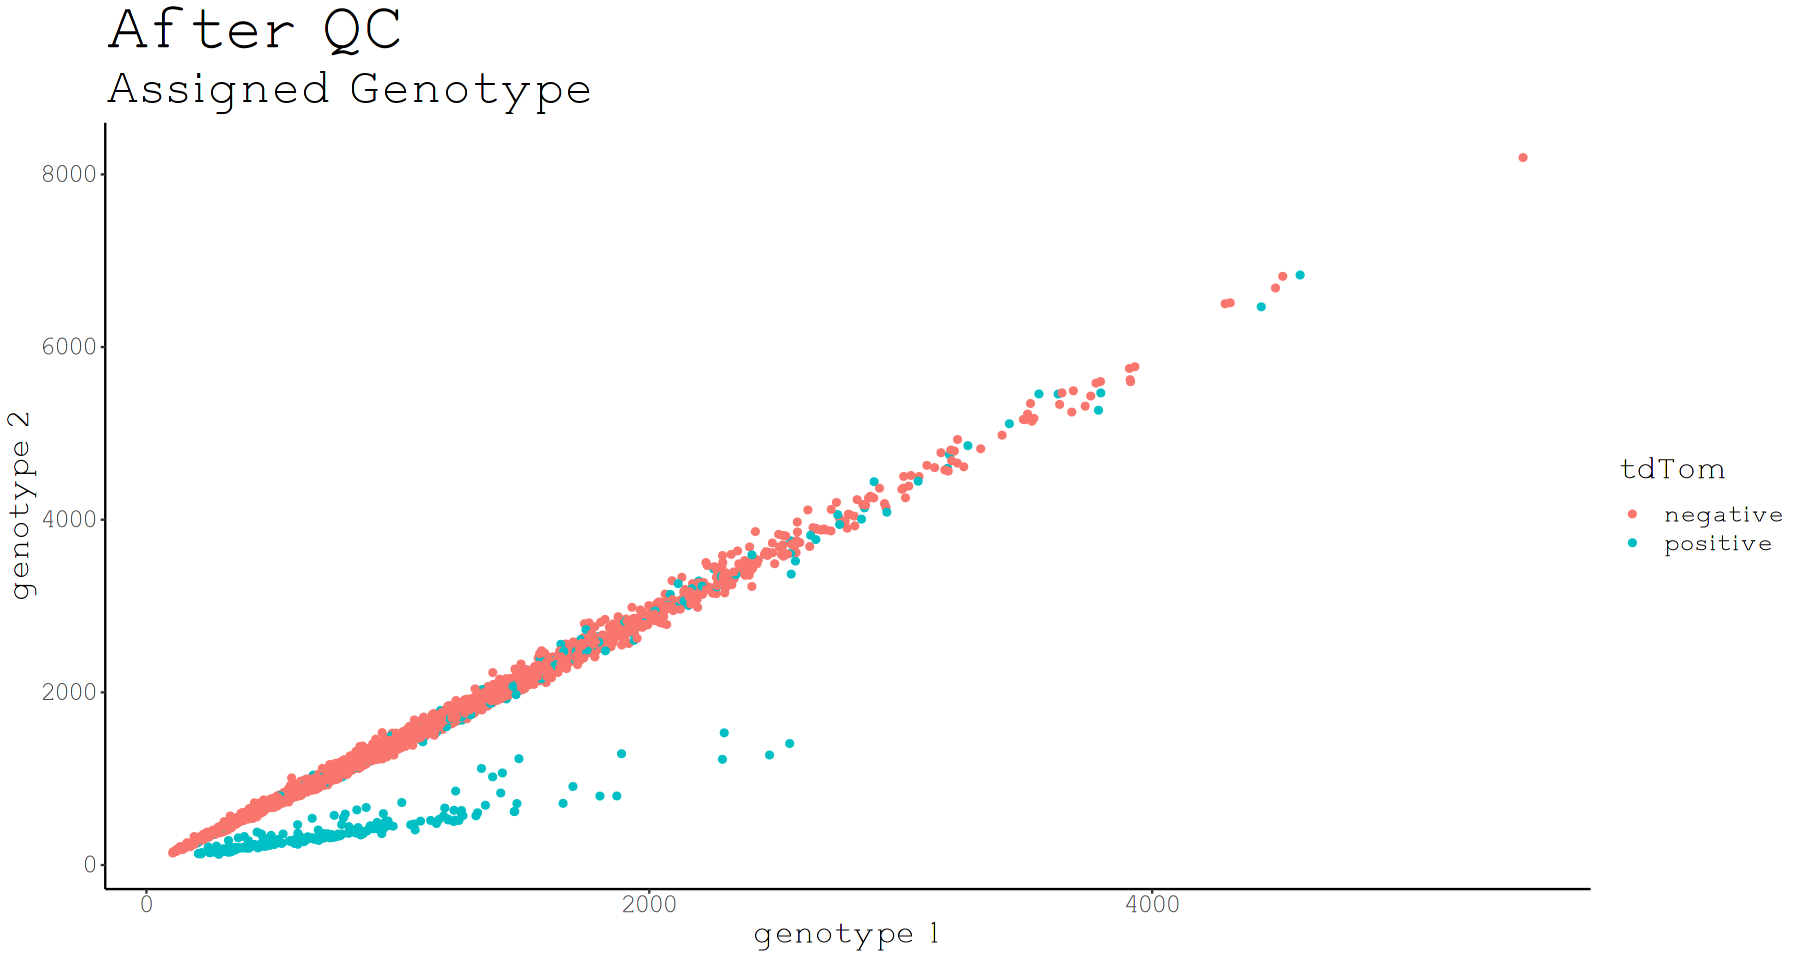

In [69]:
ggplot(merge, aes(cluster0, cluster1, color=tdTom)) + 
    geom_point() + 
    labs(title = "After QC",
        subtitle = "Assigned Genotype") + 
    xlab('genotype 1') + 
    ylab('genotype 2') + 
    theme_classic() + 
    theme + theme(plot.title = element_text(size=40), plot.subtitle = element_text(size = 30))